
# MATH 5010-Lab 3



In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm, chi2, gamma, invgamma
rng = np.random.default_rng(2025)


# Study example, based on homework 9 solutions:


### Hypothesis Testing: Poisson & Exponential (Classical + Bayesian)

- Likelihood Ratio Tests (LRT)
- p-values
- Type I/II errors
- Bayesian tests (Gamma & Inverse-Gamma priors)
- Poisson and Exponential models


## Part 1 — Poisson Hypothesis Test

We test:

$$
H_0: \lambda = \lambda_0
\qquad vs.\qquad
H_1: \lambda > \lambda_0.
$$


In [2]:

# simulate Poisson data
n = 40
lambda0 = 5
X = rng.poisson(lam=lambda0, size=n)
S = X.sum()
xbar = X.mean()
xbar


np.float64(5.325)

### Classical LRT and p-value

In [3]:

# CLT z-test for Poisson mean
z = (xbar - lambda0)/np.sqrt(lambda0/n)
p_value = 1 - norm.cdf(z)
z, p_value


(np.float64(0.9192388155425122), np.float64(0.17898533632216396))

### Bayesian Test for Poisson Mean (Gamma prior)

In [4]:

# Bayesian Poisson test: Gamma(a,b) prior
a, b = 2, 1
post_shape = a + S
post_rate = b + n

# Gamma CDF for posterior probability P(λ ≤ λ0 | data)
post_cdf = gamma.cdf(lambda0, a=post_shape, scale=1/post_rate)

post_shape, post_rate, post_cdf


(np.int64(215), 41, np.float64(0.2514163565334182))


## Part 2 — Exponential Hypothesis Test

Model:  
$$
X_i \sim \mathrm{Exp}(\mu).
$$

Test:

$$
H_0: \mu = \mu_0
\qquad vs.\qquad
H_1: \mu > \mu_0.
$$


In [5]:

# simulate exponential data
n2 = 30
mu0 = 10
X2 = rng.exponential(scale=mu0, size=n2)
S2 = X2.sum()
xbar2 = X2.mean()
xbar2


np.float64(12.309260086707004)

### Classical LRT Using Chi-Square Distribution

In [6]:

T = 2 * n2 * xbar2 / mu0
p_value2 = 1 - chi2.cdf(T, df=2*n2)
T, p_value2


(np.float64(73.85556052024202), np.float64(0.10774510335765575))

### Bayesian Test for Exponential Mean (Inverse-Gamma prior)

In [7]:

# Bayesian exponential test
a2, b2 = 3, 10
post_shape2 = a2 + n2
post_scale2 = b2 + S2  # inverse-gamma uses "scale"

post_cdf2 = invgamma.cdf(mu0, a=post_shape2, scale=post_scale2)

post_shape2, post_scale2, post_cdf2


(33, np.float64(379.2778026012101), np.float64(0.19055045199442666))

## Part 3 — Visualization

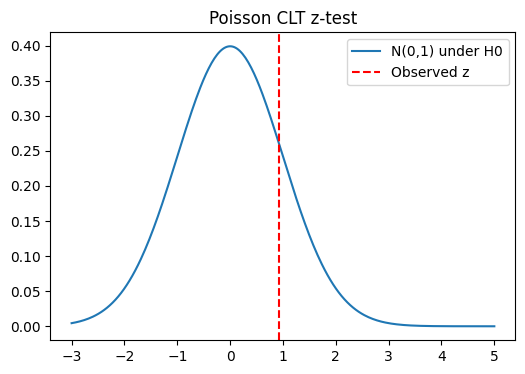

In [8]:

# Poisson z-test visualization
zgrid = np.linspace(-3, 5, 300)
plt.figure(figsize=(6,4))
plt.plot(zgrid, norm.pdf(zgrid), label="N(0,1) under H0")
plt.axvline(z, color='red', linestyle='--', label='Observed z')
plt.title("Poisson CLT z-test")
plt.legend()
plt.show()


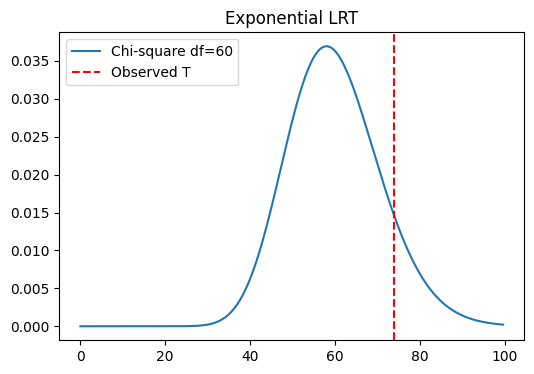

In [9]:

# Exponential LRT visualization
grid = np.linspace(0, chi2.ppf(0.999, 2*n2), 300)
plt.figure(figsize=(6,4))
plt.plot(grid, chi2.pdf(grid, 2*n2), label=f"Chi-square df={2*n2}")
plt.axvline(T, color='red', linestyle='--', label='Observed T')
plt.title("Exponential LRT")
plt.legend()
plt.show()


# Your work, based on Lecture Notes

1. Do the same work above for the mean in Normal Distribuiton (with and without known variance $\sigma^2$)

2. Do the same work above for Bernoulli Distribuiton


For each quesiton:
- Likelihood Ratio Tests (LRT)
- p-values
- Type I/II errors
- Bayesian tests (Gamma & Inverse-Gamma priors)
- Poisson and Exponential models
- Draw the graph for Visualization